Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded cached weight-init results - skipping retraining.


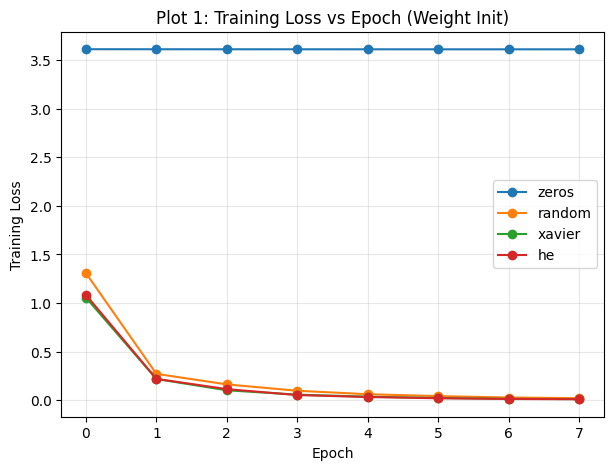

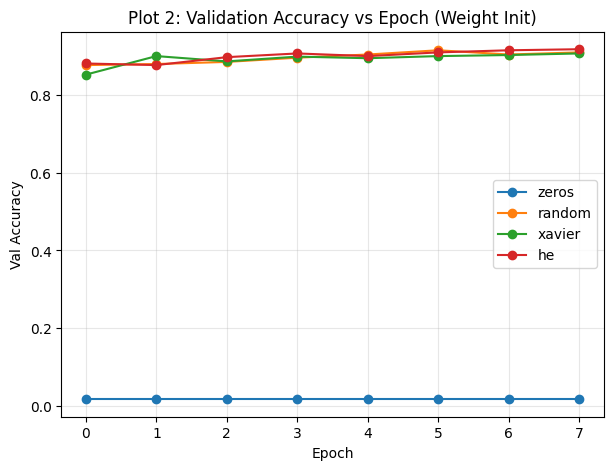

Loaded cached regularization results - skipping retraining.


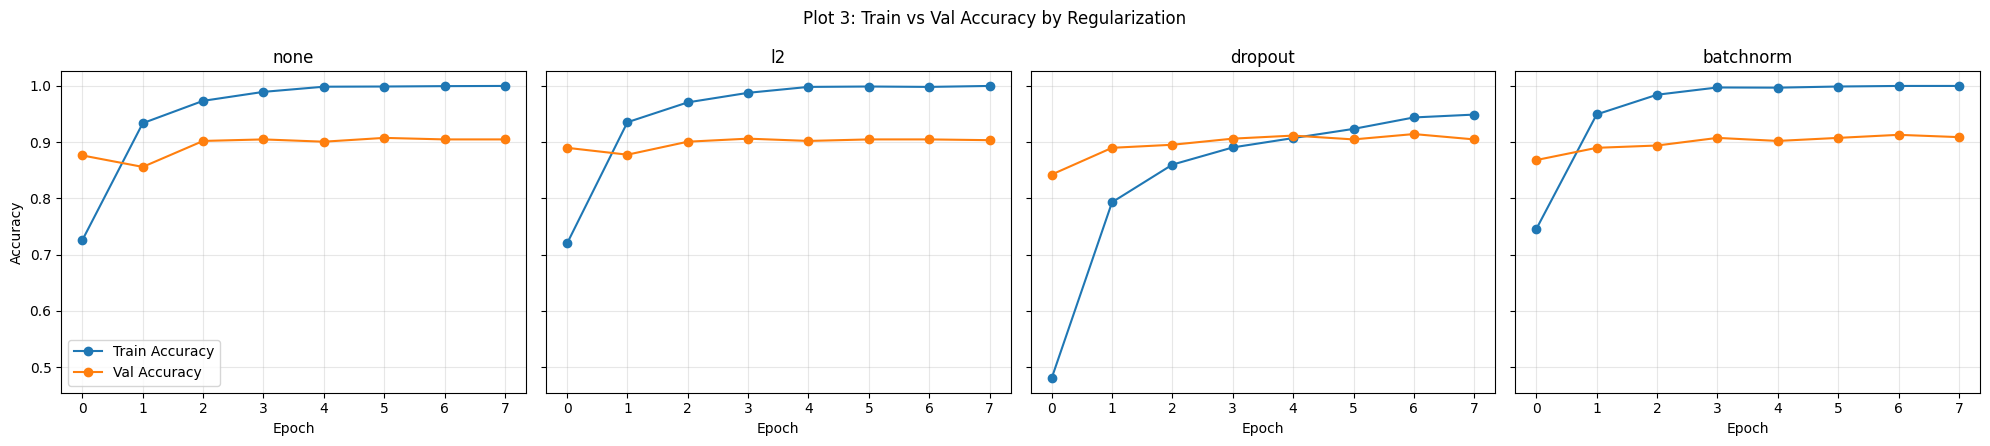

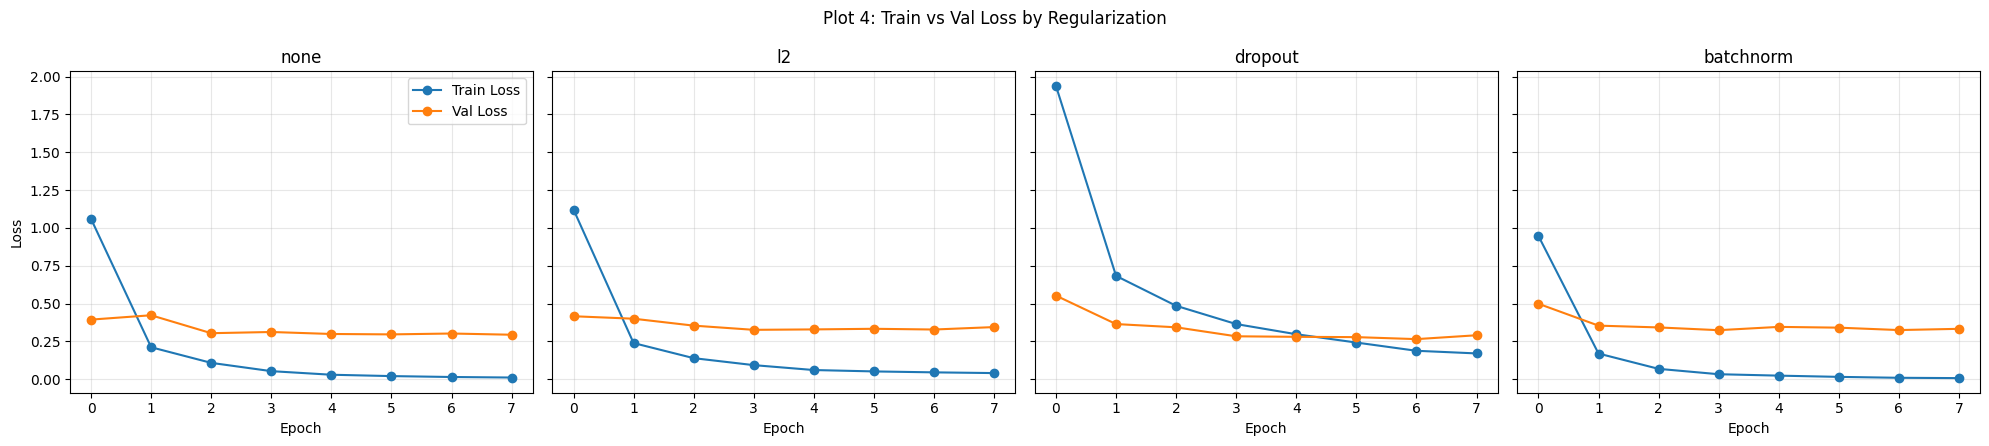

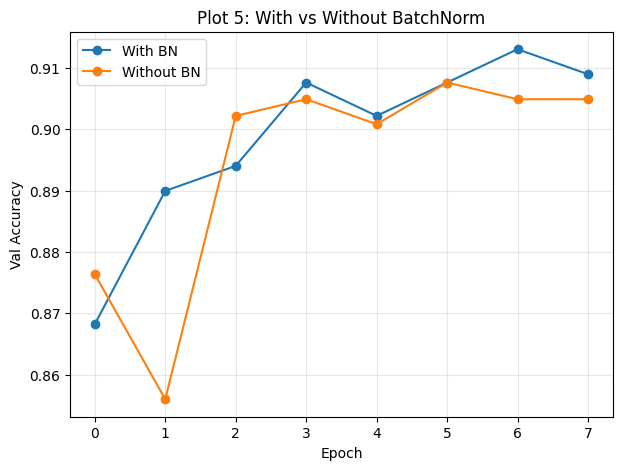

Loaded cached optimizer results - skipping retraining.


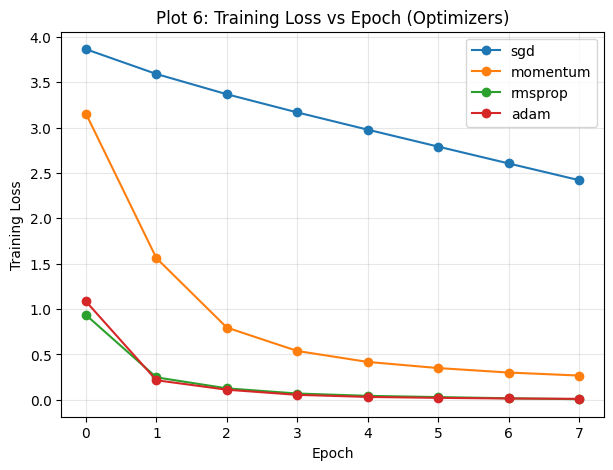

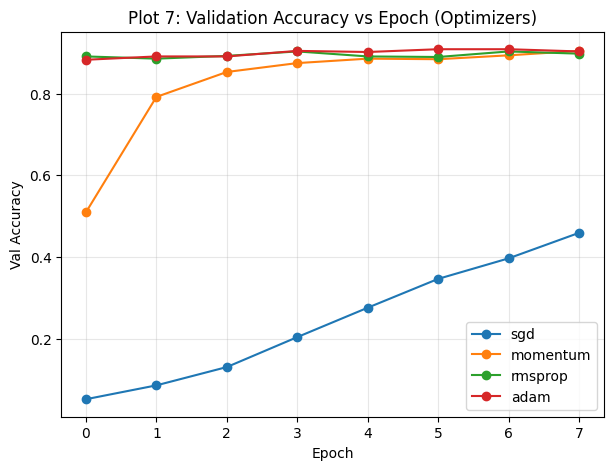


Optimizer FinalLoss   BestValAcc  EpochConv Time(s)   
sgd       2.4205      0.4592      8         125.7     
momentum  0.2674      0.9049      8         124.6     
rmsprop   0.0066      0.9035      4         130.6     
adam      0.0111      0.9090      6         146.7     
Loaded cached hyperparameter sweep results - skipping retraining.


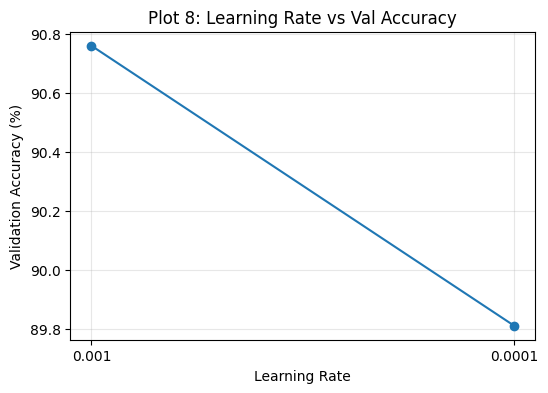

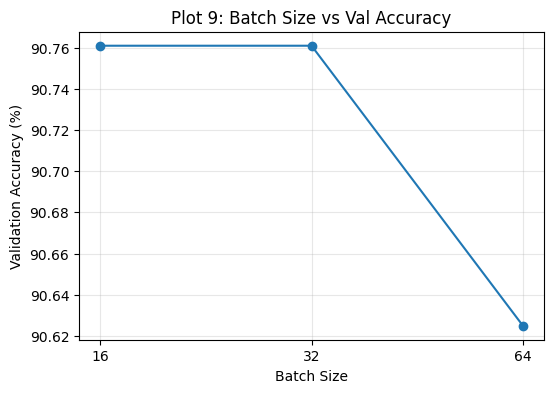

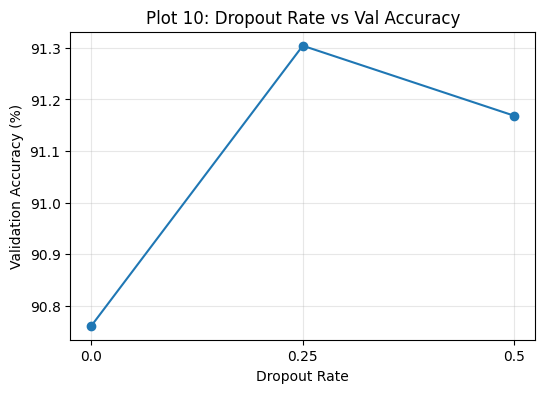

Loaded cached transfer-learning results - skipping retraining.


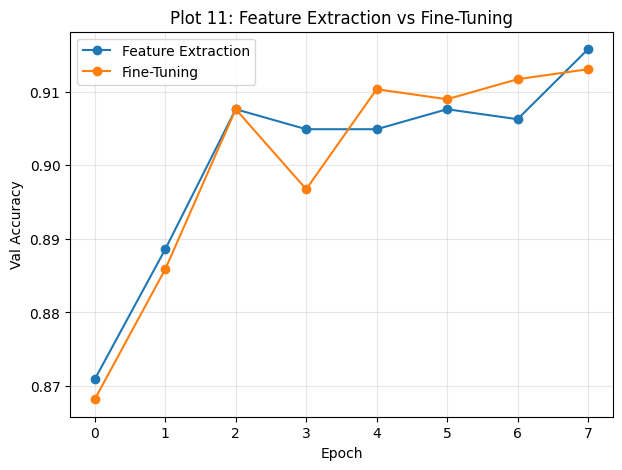

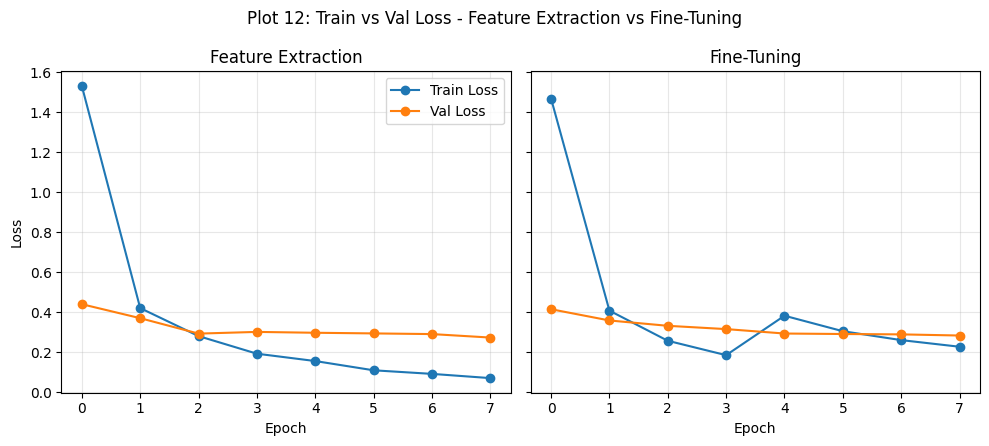

Loaded cached CV results from cv_results.json - skipping retraining.


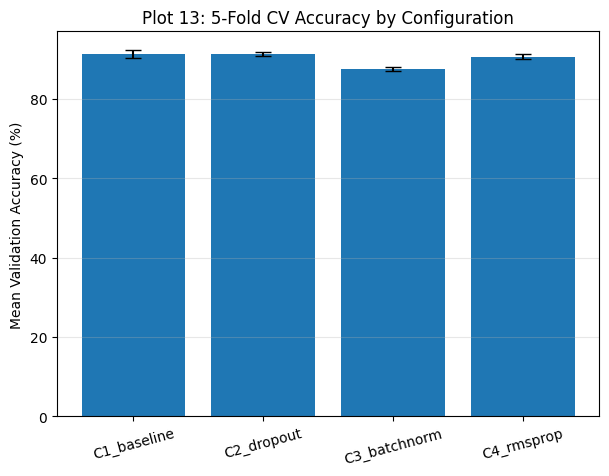

Best CV config: C1_baseline (0.9136 +/- 0.0104)
Loaded cached final results - skipping retraining and re-evaluation.


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


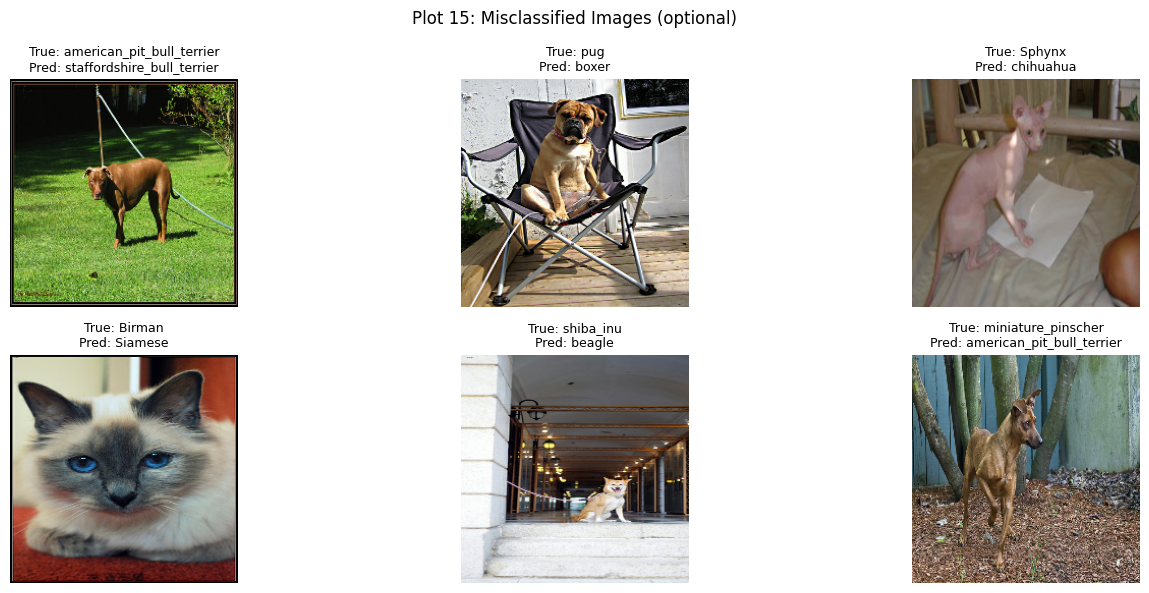

NewA_frozen: 0.9141 +/- 0.0028
NewB_partial_unfreeze: 0.8872 +/- 0.0064


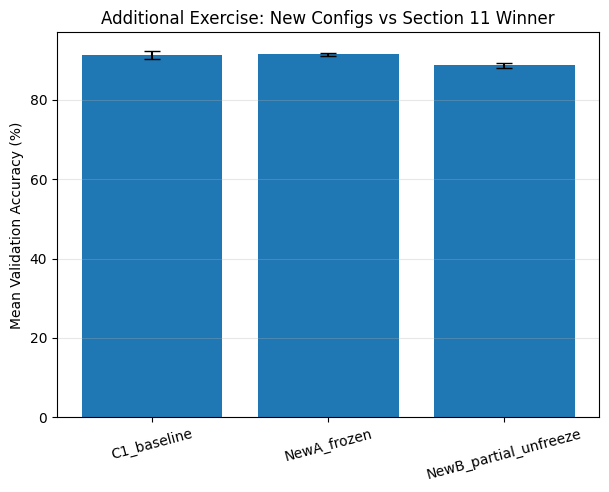


Additional Exercise - comparison with the Section 11 winner:
C1_baseline              0.9136 +/- 0.0104
NewA_frozen              0.9141 +/- 0.0028
NewB_partial_unfreeze    0.8872 +/- 0.0064

OVERALL RESULTS SUMMARY 
Single train/val-split studies (val-accuracy, NOT cross-validated):
  Weight init          : {'zeros': 0.01766304299235344, 'random': 0.914402186870575, 'xavier': 0.90625, 'he': 0.917119562625885}
  Regularization       : {'none': 0.907608687877655, 'l2': 0.90625, 'dropout': 0.914402186870575, 'batchnorm': 0.9130434989929199}
  Optimizer            : {'sgd': 0.45923912525177, 'momentum': 0.904891312122345, 'rmsprop': 0.9035326242446899, 'adam': 0.9089673757553101}
  Hyperparameter sweep : {'lr': [[0.001, 0.907608687877655], [0.0001, 0.898097813129425]], 'batch_size': [[16, 0.907608687877655], [32, 0.907608687877655], [64, 0.90625]], 'dropout': [[0.0, 0.907608687877655], [0.25, 0.9130434989929199], [0.5, 0.9116848111152649]]}

Cross-validated configs:
  C1_baseline         

In [1]:
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers, optimizers, regularizers
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

SEED = 42
IMG_SIZE = 224
NUM_CLASSES = 37
BATCH_SIZE_DEFAULT = 32

EPOCHS_STUDY = 8      # epochs for each comparison experiment (Sections 5-10)
EPOCHS_FINAL = 15     # epochs for the final retrained model (Section 12)
CV_EPOCHS = 6         # epochs per fold in 5-fold CV (Sections 11 and 16)
SUBSET_FRACTION = 1.0  # full training data

try:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_DIR = "/content/drive/MyDrive/cs3807_exp5_results"
except ImportError:
    OUTPUT_DIR = "results"

os.makedirs(OUTPUT_DIR, exist_ok=True)
tf.random.set_seed(SEED)
np.random.seed(SEED)


def save_json(obj, name):
    with open(os.path.join(OUTPUT_DIR, name), "w") as f:
        json.dump(obj, f)


def load_json(name):
    path = os.path.join(OUTPUT_DIR, name)
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

# Data pipeline

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return preprocess_input(image), label


def build_pipeline(raw_ds, batch_size, shuffle=False, subset_fraction=1.0):
    ds = raw_ds
    if subset_fraction < 1.0:
        card = raw_ds.cardinality().numpy()
        if card > 0:
            ds = ds.take(int(card * subset_fraction))
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def load_full_train_arrays(subset_fraction=1.0):
    # Loaded as numpy so K-Fold can re-slice it differently per fold.
    ds = tfds.load("oxford_iiit_pet", split="train", as_supervised=True)
    images, labels = [], []
    for img, label in tfds.as_numpy(ds):
        images.append(tf.image.resize(img, (IMG_SIZE, IMG_SIZE)).numpy().astype("uint8"))
        labels.append(label)
    images, labels = np.array(images, dtype="uint8"), np.array(labels, dtype="int32")
    if subset_fraction < 1.0:
        n = int(len(images) * subset_fraction)
        idx = np.random.RandomState(SEED).choice(len(images), n, replace=False)
        images, labels = images[idx], labels[idx]
    return images, labels


def make_ds_from_arrays(images, labels, batch_size, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    ds = ds.map(lambda i, l: (preprocess_input(tf.cast(i, tf.float32)), l), num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Model

def build_model(init="he", dropout_rate=0.0, l2_reg=0.0, use_batchnorm=False, trainable_base=False, fine_tune_at=None):
    # Only the new classifier head gets re-initialized; MobileNetV2's conv weights stay ImageNet-pretrained .
    init_map = {
        "zeros": keras.initializers.Zeros(),
        "random": keras.initializers.RandomNormal(stddev=0.05, seed=SEED),
        "xavier": keras.initializers.GlorotUniform(seed=SEED),
        "he": keras.initializers.HeNormal(seed=SEED),
    }
    kernel_init = init_map[init]
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None

    base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
    base.trainable = trainable_base
    if trainable_base and fine_tune_at is not None:
        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation="relu", kernel_initializer=kernel_init, kernel_regularizer=reg)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", kernel_initializer=kernel_init)(x)
    return keras.Model(inputs, outputs), base


def compile_model(model, optimizer_name="adam", lr=1e-3):
    opt_map = {
        "sgd": optimizers.SGD(learning_rate=lr),
        "momentum": optimizers.SGD(learning_rate=lr, momentum=0.9),
        "rmsprop": optimizers.RMSprop(learning_rate=lr),
        "adam": optimizers.Adam(learning_rate=lr),
    }
    model.compile(optimizer=opt_map[optimizer_name], loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def train_model(model, train_ds, val_ds, epochs, verbose=1):
    return model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=verbose)

#  Plotting

def to_hist_dict(h):
    return h.history if hasattr(h, "history") else h


def plot_curves(histories, metric, title, xlabel, ylabel, filename):
    plt.figure(figsize=(7, 5))
    for label, hist in histories.items():
        plt.plot(to_hist_dict(hist)[metric], marker="o", label=label)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.legend(); plt.grid(alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_train_val_grid(histories, metric, ylabel, title, filename):
    names = list(histories.keys())
    fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 4.5), sharey=True)
    if len(names) == 1:
        axes = [axes]
    for ax, name in zip(axes, names):
        h = to_hist_dict(histories[name])
        ax.plot(h[metric], marker="o", label=f"Train {ylabel}")
        ax.plot(h[f"val_{metric}"], marker="o", label=f"Val {ylabel}")
        ax.set_title(name); ax.set_xlabel("Epoch"); ax.grid(alpha=0.3)
    axes[0].set_ylabel(ylabel); axes[0].legend()
    fig.suptitle(title); fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show(); plt.close()


def plot_sweep(pairs, xlabel, title, filename):
    xs = [str(p[0]) for p in pairs]
    ys = [p[1] * 100 for p in pairs]
    plt.figure(figsize=(6, 4))
    plt.plot(xs, ys, marker="o")
    plt.title(title); plt.xlabel(xlabel); plt.ylabel("Validation Accuracy (%)"); plt.grid(alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

# Weight Initialization

def experiment_weight_init(train_ds, val_ds):
    histories = load_json("init_histories.json")
    if histories is None:
        histories = {}
        for init in ["zeros", "random", "xavier", "he"]:
            model, _ = build_model(init=init)
            model = compile_model(model, "adam", 1e-3)
            histories[init] = train_model(model, train_ds, val_ds, EPOCHS_STUDY).history
            keras.backend.clear_session()
        save_json(histories, "init_histories.json")
    else:
        print("Loaded cached weight-init results - skipping retraining.")

    plot_curves(histories, "loss", "Plot 1: Training Loss vs Epoch (Weight Init)", "Epoch", "Training Loss", "plot1_init_loss.png")
    plot_curves(histories, "val_accuracy", "Plot 2: Validation Accuracy vs Epoch (Weight Init)", "Epoch", "Val Accuracy", "plot2_init_valacc.png")
    return histories

# Regularization & BatchNorm

def experiment_regularization(train_ds, val_ds):
    histories = load_json("reg_histories.json")
    if histories is None:
        configs = {
            "none": dict(dropout_rate=0.0, l2_reg=0.0, use_batchnorm=False),
            "l2": dict(dropout_rate=0.0, l2_reg=1e-4, use_batchnorm=False),
            "dropout": dict(dropout_rate=0.5, l2_reg=0.0, use_batchnorm=False),
            "batchnorm": dict(dropout_rate=0.0, l2_reg=0.0, use_batchnorm=True),
        }
        histories = {}
        for name, cfg in configs.items():
            model, _ = build_model(init="he", **cfg)
            model = compile_model(model, "adam", 1e-3)
            histories[name] = train_model(model, train_ds, val_ds, EPOCHS_STUDY).history
            keras.backend.clear_session()
        save_json(histories, "reg_histories.json")
    else:
        print("Loaded cached regularization results - skipping retraining.")

    plot_train_val_grid(histories, "accuracy", "Accuracy", "Plot 3: Train vs Val Accuracy by Regularization", "plot3_train_val_accuracy.png")
    plot_train_val_grid(histories, "loss", "Loss", "Plot 4: Train vs Val Loss by Regularization", "plot4_train_val_loss.png")
    plot_curves({"With BN": histories["batchnorm"], "Without BN": histories["none"]}, "val_accuracy",
                "Plot 5: With vs Without BatchNorm", "Epoch", "Val Accuracy", "plot5_batchnorm.png")
    return histories

# Optimizers

def experiment_optimizers(train_ds, val_ds):
    cached = load_json("opt_results.json")
    if cached is None:
        histories, rows = {}, []
        for opt in ["sgd", "momentum", "rmsprop", "adam"]:
            model, _ = build_model(init="he")
            model = compile_model(model, opt, 1e-3)
            t0 = time.time()
            hist = train_model(model, train_ds, val_ds, EPOCHS_STUDY)
            elapsed = time.time() - t0
            histories[opt] = hist.history
            rows.append([opt, hist.history["loss"][-1], max(hist.history["val_accuracy"]),
                         int(np.argmax(hist.history["val_accuracy"])) + 1, elapsed])
            keras.backend.clear_session()
        save_json({"histories": histories, "rows": rows}, "opt_results.json")
    else:
        histories, rows = cached["histories"], cached["rows"]
        print("Loaded cached optimizer results - skipping retraining.")

    plot_curves(histories, "loss", "Plot 6: Training Loss vs Epoch (Optimizers)", "Epoch", "Training Loss", "plot6_optimizer_loss.png")
    plot_curves(histories, "val_accuracy", "Plot 7: Validation Accuracy vs Epoch (Optimizers)", "Epoch", "Val Accuracy", "plot7_optimizer_valacc.png")

    print(f"\n{'Optimizer':<10}{'FinalLoss':<12}{'BestValAcc':<12}{'EpochConv':<10}{'Time(s)':<10}")
    for r in rows:
        print(f"{r[0]:<10}{r[1]:<12.4f}{r[2]:<12.4f}{r[3]:<10}{r[4]:<10.1f}")
    return histories, rows

# Hyperparameter Tuning

def experiment_hyperparams(train_pipeline_fn, val_pipeline_fn):
    results = load_json("hp_results.json")
    if results is None:
        results = {"lr": [], "batch_size": [], "dropout": []}

        for lr in [1e-3, 1e-4]:
            model, _ = build_model(init="he")
            model = compile_model(model, "adam", lr)
            hist = train_model(model, train_pipeline_fn(BATCH_SIZE_DEFAULT), val_pipeline_fn(BATCH_SIZE_DEFAULT), EPOCHS_STUDY)
            results["lr"].append([lr, max(hist.history["val_accuracy"])])
            keras.backend.clear_session()

        for bs in [16, 32, 64]:
            model, _ = build_model(init="he")
            model = compile_model(model, "adam", 1e-3)
            hist = train_model(model, train_pipeline_fn(bs), val_pipeline_fn(bs), EPOCHS_STUDY)
            results["batch_size"].append([bs, max(hist.history["val_accuracy"])])
            keras.backend.clear_session()

        for dr in [0.0, 0.25, 0.5]:
            model, _ = build_model(init="he", dropout_rate=dr)
            model = compile_model(model, "adam", 1e-3)
            hist = train_model(model, train_pipeline_fn(BATCH_SIZE_DEFAULT), val_pipeline_fn(BATCH_SIZE_DEFAULT), EPOCHS_STUDY)
            results["dropout"].append([dr, max(hist.history["val_accuracy"])])
            keras.backend.clear_session()

        save_json(results, "hp_results.json")
    else:
        print("Loaded cached hyperparameter sweep results - skipping retraining.")

    plot_sweep(results["lr"], "Learning Rate", "Plot 8: Learning Rate vs Val Accuracy", "plot8_lr.png")
    plot_sweep(results["batch_size"], "Batch Size", "Plot 9: Batch Size vs Val Accuracy", "plot9_batch_size.png")
    plot_sweep(results["dropout"], "Dropout Rate", "Plot 10: Dropout Rate vs Val Accuracy", "plot10_dropout.png")
    return results

# Transfer Learning vs Fine-Tuning

def experiment_transfer_finetune(train_ds, val_ds):
    cached = load_json("transfer_finetune.json")
    if cached is None:
        model_a, _ = build_model(init="he", dropout_rate=0.3, trainable_base=False)
        model_a = compile_model(model_a, "adam", 1e-3)
        hist_a = train_model(model_a, train_ds, val_ds, EPOCHS_STUDY).history
        keras.backend.clear_session()

        model_b, base_b = build_model(init="he", dropout_rate=0.3, trainable_base=False)
        model_b = compile_model(model_b, "adam", 1e-3)
        p1 = max(1, EPOCHS_STUDY // 2)
        p2 = EPOCHS_STUDY - p1
        hist_b1 = train_model(model_b, train_ds, val_ds, p1)

        fine_tune_at = max(0, len(base_b.layers) - 30)
        base_b.trainable = True
        for layer in base_b.layers[:fine_tune_at]:
            layer.trainable = False
        model_b = compile_model(model_b, "adam", 1e-5)  # small LR
        hist_b2 = train_model(model_b, train_ds, val_ds, p2)

        merged_b = {k: hist_b1.history[k] + hist_b2.history[k] for k in ["accuracy", "val_accuracy", "loss", "val_loss"]}
        keras.backend.clear_session()
        save_json({"feature_extraction": hist_a, "fine_tuning": merged_b}, "transfer_finetune.json")
    else:
        hist_a, merged_b = cached["feature_extraction"], cached["fine_tuning"]
        print("Loaded cached transfer-learning results - skipping retraining.")

    plot_curves({"Feature Extraction": hist_a, "Fine-Tuning": merged_b}, "val_accuracy",
                "Plot 11: Feature Extraction vs Fine-Tuning", "Epoch", "Val Accuracy", "plot11_transfer_vs_finetune.png")

    plot_train_val_grid({"Feature Extraction": hist_a, "Fine-Tuning": merged_b}, "loss", "Loss",
                         "Plot 12: Train vs Val Loss - Feature Extraction vs Fine-Tuning", "plot12_finetune_loss.png")
    return hist_a, merged_b

# K-Fold Cross-Validation

def experiment_kfold_cv(images, labels, configs, k=5, epochs=3, cache_name="cv_results.json"):
    cv_results = load_json(cache_name)
    if cv_results is not None:
        print(f"Loaded cached CV results from {cache_name} - skipping retraining.")
        return cv_results

    kf = KFold(n_splits=k, shuffle=True, random_state=SEED)
    cv_results = {}
    for cfg_name, cfg in configs.items():
        fold_accs = []
        for train_idx, val_idx in kf.split(images):
            model, _ = build_model(**cfg["model_kwargs"])
            model = compile_model(model, cfg["optimizer"], cfg["lr"])
            bs = cfg.get("batch_size", BATCH_SIZE_DEFAULT)
            train_ds = make_ds_from_arrays(images[train_idx], labels[train_idx], bs, shuffle=True)
            val_ds = make_ds_from_arrays(images[val_idx], labels[val_idx], bs)
            model.fit(train_ds, epochs=epochs, verbose=0)
            _, acc = model.evaluate(val_ds, verbose=0)
            fold_accs.append(acc)
            keras.backend.clear_session()
        mean_acc, sd_acc = float(np.mean(fold_accs)), float(np.std(fold_accs))
        cv_results[cfg_name] = {"folds": fold_accs, "mean": mean_acc, "sd": sd_acc}
        print(f"{cfg_name}: {mean_acc:.4f} +/- {sd_acc:.4f}")
    save_json(cv_results, cache_name)
    return cv_results


def plot_cv_results(cv_results, title, filename):
    names = list(cv_results.keys())
    means = [cv_results[n]["mean"] * 100 for n in names]
    sds = [cv_results[n]["sd"] * 100 for n in names]
    plt.figure(figsize=(7, 5))
    plt.bar(names, means, yerr=sds, capsize=6)
    plt.title(title)
    plt.ylabel("Mean Validation Accuracy (%)")
    plt.xticks(rotation=15); plt.grid(alpha=0.3, axis="y")
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

# Final Model Evaluation

def final_evaluation(images, labels, best_cfg, best_cfg_name, cv_results, test_ds):
    ckpt_path = os.path.join(OUTPUT_DIR, "final_model.weights.h5")

    cached = load_json("final_results.json")
    if cached is not None:
        print("Loaded cached final results - skipping retraining and re-evaluation.")
        model, _ = build_model(**best_cfg["model_kwargs"])
        model = compile_model(model, best_cfg["optimizer"], best_cfg["lr"])
        model.load_weights(ckpt_path)
        y_true, y_pred = np.array(cached["y_true"]), np.array(cached["y_pred"])
        return model, cached, y_true, y_pred

    bs = best_cfg.get("batch_size", BATCH_SIZE_DEFAULT)
    full_ds = make_ds_from_arrays(images, labels, bs, shuffle=True)

    model, _ = build_model(**best_cfg["model_kwargs"])
    model = compile_model(model, best_cfg["optimizer"], best_cfg["lr"])

    state = load_json("final_train_state.json") or {"epoch": 0}
    if os.path.exists(ckpt_path) and state["epoch"] > 0:
        model.load_weights(ckpt_path)
        print(f"Resuming final training from epoch {state['epoch']}/{EPOCHS_FINAL}")

    t0 = time.time()
    if state["epoch"] < EPOCHS_FINAL:
        ckpt_cb = keras.callbacks.ModelCheckpoint(ckpt_path, save_weights_only=True)
        state_cb = keras.callbacks.LambdaCallback(
            on_epoch_end=lambda epoch, logs: save_json({"epoch": epoch + 1}, "final_train_state.json")
        )
        model.fit(full_ds, epochs=EPOCHS_FINAL, initial_epoch=state["epoch"],
                  callbacks=[ckpt_cb, state_cb], verbose=1)
    train_time = time.time() - t0

    y_true, y_pred = [], []
    for imgs, labs in test_ds:
        preds = model.predict(imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labs.numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    results = dict(
        test_acc=float(np.mean(y_true == y_pred)),
        precision=float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        recall=float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        f1=float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        train_time=train_time,
        n_params=int(model.count_params()),
        cv_mean_accuracy=cv_results[best_cfg_name]["mean"],
        cv_sd=cv_results[best_cfg_name]["sd"],
        y_true=y_true.tolist(),
        y_pred=y_pred.tolist(),
    )
    print("\nFinal metrics:", {k: v for k, v in results.items() if k not in ("y_true", "y_pred")})
    save_json(results, "final_results.json")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 9))
    plt.imshow(cm, cmap="Blues")
    plt.title("Plot 14: Confusion Matrix (Test Set)")
    plt.xlabel("Predicted class index"); plt.ylabel("True class index")
    plt.colorbar()
    plt.savefig(os.path.join(OUTPUT_DIR, "plot14_confusion_matrix.png"), dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

    return model, results, y_true, y_pred


def show_misclassified(model, test_ds, class_names, n=6):
    shown = []
    for imgs, labs in test_ds:
        preds = np.argmax(model.predict(imgs, verbose=0), axis=1)
        labs_np = labs.numpy()
        for i in range(len(labs_np)):
            if preds[i] != labs_np[i] and len(shown) < n:
                shown.append((imgs[i].numpy(), labs_np[i], preds[i]))
        if len(shown) >= n:
            break
    if not shown:
        return
    plt.figure(figsize=(15, 6))
    for idx, (img, true_l, pred_l) in enumerate(shown):
        plt.subplot(2, 3, idx + 1)
        plt.imshow(np.clip((img + 1) / 2.0, 0, 1))  # undo -1..1 scaling for display
        plt.title(f"True: {class_names[true_l]}\nPred: {class_names[pred_l]}", fontsize=9)
        plt.axis("off")
    plt.suptitle("Plot 15: Misclassified Images (optional)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "plot15_misclassified.png"), dpi=150, bbox_inches="tight")
    plt.show(); plt.close()

# Additional Exercise
# Two NEW combinations of learning rate, dropout, batch size and fine-tuning strategy, evaluated with the same 5-fold CV, compared against the configuration selected in Section 11.

def experiment_additional_exercise(images, labels, cv_results, best_cfg_name):
    extra_configs = {
        "NewA_frozen": dict(model_kwargs=dict(init="he", dropout_rate=0.4, trainable_base=False),
                             optimizer="adam", lr=5e-4, batch_size=32),
        "NewB_partial_unfreeze": dict(model_kwargs=dict(init="he", dropout_rate=0.2, trainable_base=True, fine_tune_at=100),
                                       optimizer="adam", lr=1e-4, batch_size=16),
    }
    extra_cv_results = experiment_kfold_cv(images, labels, extra_configs, k=5, epochs=CV_EPOCHS,
                                            cache_name="extra_cv_results.json")

    all_compare = {best_cfg_name: cv_results[best_cfg_name], **extra_cv_results}
    plot_cv_results(all_compare, "Additional Exercise: New Configs vs Section 11 Winner", "plot16_additional_exercise.png")

    print("\nAdditional Exercise - comparison with the Section 11 winner:")
    for name, r in all_compare.items():
        print(f"{name:<25}{r['mean']:.4f} +/- {r['sd']:.4f}")
    return extra_cv_results

# Overall Results summary

def print_summary(init_histories, reg_histories, opt_histories, hp_results,
                   cv_results, extra_cv_results, best_cfg_name, final_results):
    def best_val_acc(histories_dict):
        return {name: max(to_hist_dict(h)["val_accuracy"]) for name, h in histories_dict.items()}

    all_cv = {best_cfg_name: cv_results[best_cfg_name], **extra_cv_results}

    print("\nOVERALL RESULTS SUMMARY ")
    print("Single train/val-split studies (val-accuracy, NOT cross-validated):")
    print("  Weight init          :", best_val_acc(init_histories))
    print("  Regularization       :", best_val_acc(reg_histories))
    print("  Optimizer            :", best_val_acc(opt_histories))
    print("  Hyperparameter sweep :", hp_results)
    print("\nCross-validated configs:")
    for name, r in all_cv.items():
        print(f"  {name:<25} CV mean={r['mean']:.4f}  CV sd={r['sd']:.4f}")
    print(f"\nFinal selected config : {best_cfg_name}")
    print(f"Final test accuracy    : {final_results['test_acc']:.4f}")
    print(f"Precision / Recall / F1: {final_results['precision']:.4f} / {final_results['recall']:.4f} / {final_results['f1']:.4f}")
    print(f"Training time          : {final_results['train_time']:.1f}s")
    print(f"Parameters             : {final_results['n_params']:,}")


train_raw = tfds.load("oxford_iiit_pet", split="train[:80%]", as_supervised=True)
val_raw = tfds.load("oxford_iiit_pet", split="train[80%:]", as_supervised=True)
test_raw, ds_info = tfds.load("oxford_iiit_pet", split="test", as_supervised=True, with_info=True)
class_names = ds_info.features["label"].names

train_ds = build_pipeline(train_raw, BATCH_SIZE_DEFAULT, shuffle=True, subset_fraction=SUBSET_FRACTION)
val_ds = build_pipeline(val_raw, BATCH_SIZE_DEFAULT, subset_fraction=SUBSET_FRACTION)
test_ds = build_pipeline(test_raw, BATCH_SIZE_DEFAULT)

init_histories = experiment_weight_init(train_ds, val_ds)
reg_histories = experiment_regularization(train_ds, val_ds)
opt_histories, opt_rows = experiment_optimizers(train_ds, val_ds)
hp_results = experiment_hyperparams(
    lambda bs: build_pipeline(train_raw, bs, shuffle=True, subset_fraction=SUBSET_FRACTION),
    lambda bs: build_pipeline(val_raw, bs, subset_fraction=SUBSET_FRACTION),
)
hist_fe, hist_ft = experiment_transfer_finetune(train_ds, val_ds)

images, labels = load_full_train_arrays(subset_fraction=SUBSET_FRACTION)
cv_configs = {
    "C1_baseline": dict(model_kwargs=dict(init="he"), optimizer="adam", lr=1e-3, batch_size=32),
    "C2_dropout": dict(model_kwargs=dict(init="he", dropout_rate=0.5), optimizer="adam", lr=1e-3, batch_size=32),
    "C3_batchnorm": dict(model_kwargs=dict(init="he", use_batchnorm=True), optimizer="adam", lr=1e-4, batch_size=32),
    "C4_rmsprop": dict(model_kwargs=dict(init="he", dropout_rate=0.25), optimizer="rmsprop", lr=1e-3, batch_size=16),
}
cv_results = experiment_kfold_cv(images, labels, cv_configs, k=5, epochs=CV_EPOCHS, cache_name="cv_results.json")
plot_cv_results(cv_results, "Plot 13: 5-Fold CV Accuracy by Configuration", "plot13_cv_results.png")

best_cfg_name = max(cv_results, key=lambda n: cv_results[n]["mean"])
print(f"Best CV config: {best_cfg_name} ({cv_results[best_cfg_name]['mean']:.4f} +/- {cv_results[best_cfg_name]['sd']:.4f})")

best_model, final_results, y_true, y_pred = final_evaluation(images, labels, cv_configs[best_cfg_name], best_cfg_name, cv_results, test_ds)
show_misclassified(best_model, test_ds, class_names, n=6)

extra_cv_results = experiment_additional_exercise(images, labels, cv_results, best_cfg_name)

print_summary(init_histories, reg_histories, opt_histories, hp_results,
              cv_results, extra_cv_results, best_cfg_name, final_results)
print(f"\nDone. Plots and results are in {OUTPUT_DIR}/")

In [3]:
!pip install -q -U protobuf tensorflow-metadata tensorflow-datasets
!pip install -q importlib_resources

^C
